In [11]:
import numpy as np
import pandas as pd

df = pd.read_csv('aircraft_performance.csv')

# Two features: speed (km/h) and fuel flow (kg/h)
X = df[['Speed_kmh', 'FuelFlow_kgph']].to_numpy()

print(X[:5])

[[226  24]
 [260  30]
 [215  22]
 [240  26]
 [250  29]]


In [12]:
from sklearn.preprocessing import StandardScaler

# Standardize each feature to zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.56335897 -1.27220378]
 [-1.42951423 -1.26570632]
 [-1.60666167 -1.27436961]
 [-1.50824643 -1.27003796]
 [-1.46888033 -1.26678923]]


k = 2: silhouette score = 0.6404
k = 3: silhouette score = 0.6898
k = 4: silhouette score = 0.7945
k = 5: silhouette score = 0.7291
k = 6: silhouette score = 0.7440


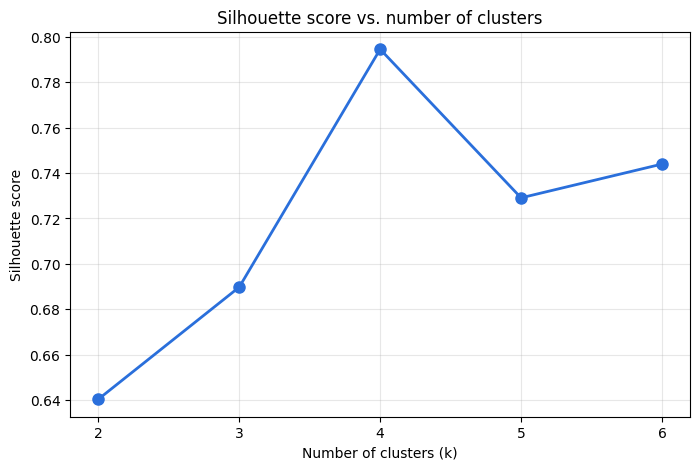

In [13]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Run k-means for k = 2..6 and record the silhouette score of each
k_values = range(2, 7)
sil_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f'k = {k}: silhouette score = {score:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(k_values, sil_scores, 'o-', color='#2a6fdb', linewidth=2, markersize=8)
plt.xticks(list(k_values))
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score vs. number of clusters')
plt.grid(alpha=0.3)
plt.show()

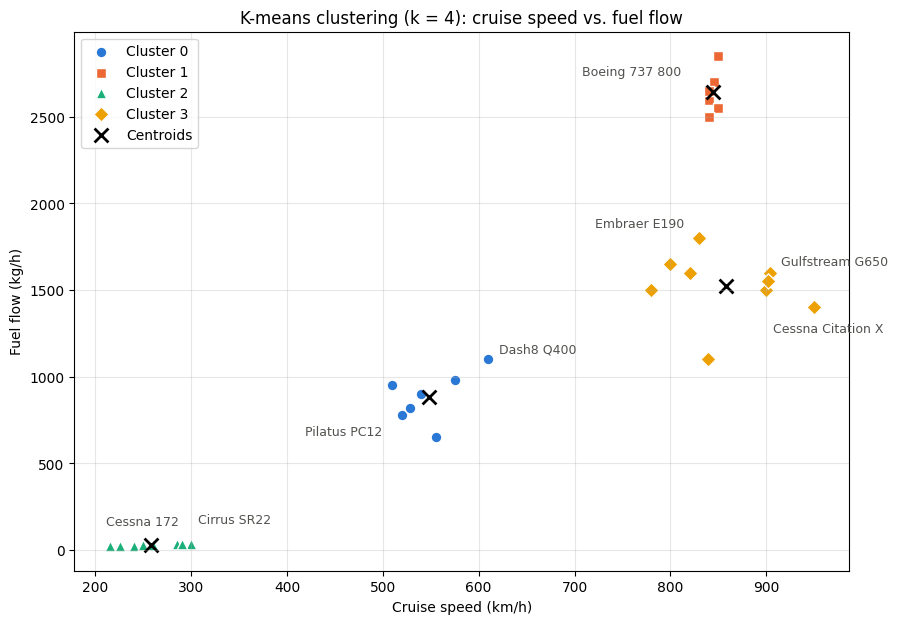

Cluster
0    [Pilatus_PC12, Beechcraft_KingAir_200, ATR_72,...
1    [Airbus_A320, Boeing_737_800, Boeing_737_MAX8,...
2    [Cessna_172, Cessna_182, Piper_PA28, Diamond_D...
3    [Embraer_E175, Embraer_E190, CRJ700, CRJ900, G...
Name: Aircraft, dtype: object


In [14]:
# Final model with k = 4
kmeans4 = KMeans(n_clusters=4, n_init=10, random_state=42)
labels4 = kmeans4.fit_predict(X_scaled)
df['Cluster'] = labels4

# Cluster centers back in original units (km/h, kg/h)
centers = scaler.inverse_transform(kmeans4.cluster_centers_)

colors = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
markers = ['o', 's', '^', 'D']

plt.figure(figsize=(10, 7))
for c in range(4):
    pts = X[labels4 == c]
    plt.scatter(pts[:, 0], pts[:, 1], color=colors[c], marker=markers[c],
                s=60, edgecolors='white', linewidths=1, label=f'Cluster {c}')
plt.scatter(centers[:, 0], centers[:, 1], color='black', marker='x',
            s=100, linewidths=2, label='Centroids')

# Label a few representative aircraft (name: text offset in points)
representatives = {
    'Cessna_172':        (-10, 15),
    'Cirrus_SR22':       (5, 15),
    'Pilatus_PC12':      (-70, -15),
    'Dash8_Q400':        (8, 5),
    'Embraer_E190':      (-75, 8),
    'Gulfstream_G650':   (8, 5),
    'Cessna_Citation_X': (-30, -18),
    'Boeing_737_800':    (-95, 5),
}
for name, offset in representatives.items():
    row = df[df['Aircraft'] == name].iloc[0]
    plt.annotate(name.replace('_', ' '), (row['Speed_kmh'], row['FuelFlow_kgph']),
                 xytext=offset, textcoords='offset points', fontsize=9, color='#52514e')

plt.xlabel('Cruise speed (km/h)')
plt.ylabel('Fuel flow (kg/h)')
plt.title('K-means clustering (k = 4): cruise speed vs. fuel flow')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

print(df.groupby('Cluster')['Aircraft'].apply(list))

### Cluster interpretation (k = 4)

- **Cluster 2: slow, very low fuel flow → general aviation piston aircraft** (≈ 258 km/h, ≈ 29 kg/h; e.g. Cessna 172, Piper PA-28, Cirrus SR22). Small reciprocating engines and propellers, light airframes with only a few seats, so fuel burn is tiny.
- **Cluster 0: moderate speed, moderate fuel flow → turboprops** (≈ 548 km/h, ≈ 883 kg/h; e.g. Pilatus PC-12, King Air, ATR 72, Dash 8 Q400). Gas turbines drive propellers, which are efficient at medium speeds and altitudes. They are much faster than piston aircraft but stay below jet speeds because propeller efficiency falls off at high Mach numbers.
- **Cluster 3: fast, medium-high fuel flow → regional and business jets** (≈ 858 km/h, ≈ 1522 kg/h; e.g. Embraer E190, CRJ900, Gulfstream G650, Citation X). Turbofans cruise near Mach 0.8, but these airframes are smaller and lighter than airliners, so they burn less fuel per hour.
- **Cluster 1: fast, very high fuel flow → narrow-body airliners** (≈ 844 km/h, ≈ 2642 kg/h; e.g. Airbus A320/A321, Boeing 737 family). They cruise at about the same speed as Cluster 3, but their much larger mass and thrust (150–200+ seats) roughly doubles the fuel burn.

**Takeaway:** cruise speed mainly separates the propulsion types (piston, turboprop, jet). Among the jets, which all cruise near Mach 0.8, fuel flow separates them by aircraft size. One edge case is the Embraer Phenom 300, a light business jet with jet speed but low fuel flow (≈ 1100 kg/h); it falls in the jet cluster but sits closer to the turboprops on the fuel-flow axis.